# 05_results.ipynb — Macrostructural Analysis and Feature Importance

**Inputs:**
- `../data/SC/SC{sid:02d}.npz` (true R&K labels for Phase 5)
- `../data/features/feature_matrix.npz` + `feature_names.txt`

**Outputs:** `../data/results/cycle_metrics.csv`, `../data/results/temporal_metrics.csv`,
`../data/results/importance.npz`, figures in `../figures/`

Covers **Phase 5** (RQ1, RQ3) and **Phase 6** (RQ2, Project 1 bridge).

**Phase 5 design note:** The Sleep-EDF Cassette sub-study uses home ambulatory
cassette recordings where subjects started/stopped the device themselves (Kemp
et al., 2000). Recording windows vary from 24 to 150 minutes and frequently
capture the latter portion of the night. This precludes full NREM-REM cycle
characterization (clinical thresholds: 15-min NREM, 5-min REM) for most
subjects. RQ1 and RQ3 therefore use a **temporal macrostructure analysis**
(first vs second half of the within-recording sleep period, n=69), following
the approach of Dijk et al. (1993) and Tononi & Cirelli (2006) who analyze
the SWS-REM gradient as a function of elapsed sleep time rather than discrete
cycles. Cycle detection results (n=13 subjects) are retained as supplementary
descriptives. Phase 6 uses the LOSO RF framework as designed.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

from src.cycle_detect import detect_cycles, first_rem_latency
from src.importance   import (permutation_importance_ova, above_null_mask,
                               band_importance, compare_project1, BANDS)

RES_DIR  = Path('../data/results')
SC_DIR   = Path('../data/SC')
FIG_DIR  = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)

STAGE_NAMES  = ['Wake', 'N1', 'N2', 'N3', 'REM']
STAGE_COLORS = ['#6baed6', '#9ecae1', '#2171b5', '#08306b', '#fc8d59']

feat_data  = np.load('../data/features/feature_matrix.npz')
X, y, sids = feat_data['X'], feat_data['y'], feat_data['subject_ids']

with open('../data/features/feature_names.txt') as f:
    feat_names = [l.strip() for l in f]

subjects = np.unique(sids)
print(f'Subjects: {len(subjects)}  |  Features: {len(feat_names)}')

Subjects: 69  |  Features: 47


---
# Phase 5 — Temporal Macrostructure (RQ1 and RQ3)

## 5.1  Supplementary: cycle detection (n=13 descriptive)

Retained for reporting. Cycle-level analysis is underpowered for this dataset
(only 13/69 subjects yield detectable cycles; 1 subject reaches 3 cycles).
Primary RQ1/RQ3 analysis uses temporal halves below.

In [2]:
records = []
for sid in subjects:
    sc_path = SC_DIR / f'SC{sid:02d}.npz'
    if not sc_path.exists():
        continue
    labels  = np.load(sc_path)['labels']
    cycles  = detect_cycles(labels)
    frl_ep  = first_rem_latency(labels)
    frl_min = frl_ep * 0.5 if frl_ep is not None else None
    for c in cycles:
        records.append({
            'subject':  sid,
            'cycle':    c.num,
            'nrem_dur': (c.nrem_end - c.nrem_start) * 0.5,
            'rem_dur':  c.rem_dur * 0.5,
            'sws_prop': c.sws_prop,
            'frl_min':  frl_min,
            'n_cycles': len(cycles),
        })

df_cyc = pd.DataFrame(records)
df_cyc.to_csv(RES_DIR / 'cycle_metrics.csv', index=False)
print(f'Cycle rows: {len(df_cyc)}  |  Subjects with cycles: {df_cyc["subject"].nunique() if len(df_cyc) else 0}')
if len(df_cyc):
    print(df_cyc.groupby('cycle')[['sws_prop','rem_dur']].mean().round(3))

Cycle rows: 18  |  Subjects with cycles: 13
       sws_prop  rem_dur
cycle                   
0         0.201    2.115
1         0.083    2.500
2         0.562    1.500


## 5.2  First-REM latency distribution (recording-relative)

Subjects with any REM: 69
First-REM latency  mean=18.5 min  median=16.5 min  SD=11.8


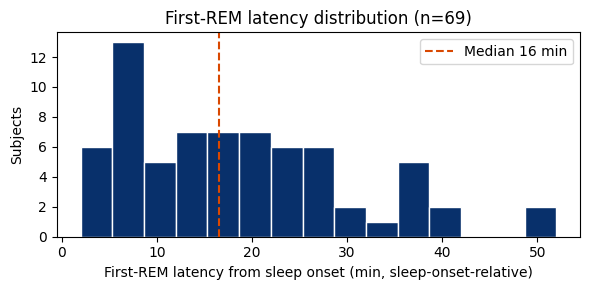

In [3]:
frl_vals = df_cyc.drop_duplicates('subject')['frl_min'].dropna() if len(df_cyc) else pd.Series([])

# Compute FRL for all 69 subjects independently (not only those with cycles)
frl_all = {}
for sid in subjects:
    sc_path = SC_DIR / f'SC{sid:02d}.npz'
    if not sc_path.exists():
        continue
    labels = np.load(sc_path)['labels']
    frl_ep = first_rem_latency(labels)
    if frl_ep is not None:
        frl_all[sid] = frl_ep * 0.5

frl_series = pd.Series(frl_all)
print(f'Subjects with any REM: {len(frl_series)}')
print(f'First-REM latency  mean={frl_series.mean():.1f} min  '
      f'median={frl_series.median():.1f} min  SD={frl_series.std():.1f}')

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(frl_series, bins=15, color='#08306b', edgecolor='white')
ax.axvline(frl_series.median(), color='#d94801', lw=1.5, ls='--',
           label=f'Median {frl_series.median():.0f} min')
ax.set_xlabel('First-REM latency from sleep onset (min, sleep-onset-relative)')
ax.set_ylabel('Subjects')
ax.set_title(f'First-REM latency distribution (n={len(frl_series)})')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'frl_distribution.png', dpi=300)
plt.show()

## 5.3  Temporal macrostructure — first vs second sleep half (n=69)

Primary RQ1/RQ3 analysis. Each subject's within-recording sleep period
(first to last non-Wake epoch) is split at the midpoint. SWS and REM
proportions are computed for each half. Sleep onset is defined as the
first non-Wake epoch; sleep offset as the last non-Wake epoch.

In [4]:
def half_props(half_labels):
    n = len(half_labels)
    if n == 0:
        return {s: np.nan for s in ['wake','n1','n2','n3','rem']}
    return {
        'wake': float(np.sum(half_labels == 0) / n),
        'n1':   float(np.sum(half_labels == 1) / n),
        'n2':   float(np.sum(half_labels == 2) / n),
        'n3':   float(np.sum(half_labels == 3) / n),
        'rem':  float(np.sum(half_labels == 4) / n),
    }

temp_records = []
for sid in subjects:
    sc_path = SC_DIR / f'SC{sid:02d}.npz'
    if not sc_path.exists():
        continue
    labels = np.load(sc_path)['labels']

    # Sleep period: first to last non-Wake epoch
    non_wake = np.where(labels != 0)[0]
    if len(non_wake) < 10:   # need at least 5 min of sleep
        continue

    sleep_labels = labels[non_wake[0]:non_wake[-1] + 1]
    mid = len(sleep_labels) // 2
    p1  = half_props(sleep_labels[:mid])
    p2  = half_props(sleep_labels[mid:])

    temp_records.append({
        'subject':          sid,
        'n_sleep_epochs':   len(sleep_labels),
        'first_sws':        p1['n3'],
        'second_sws':       p2['n3'],
        'first_rem':        p1['rem'],
        'second_rem':       p2['rem'],
        'first_n2':         p1['n2'],
        'second_n2':        p2['n2'],
        # positive delta_sws = SWS declined (first > second); expected direction
        'delta_sws':        p1['n3'] - p2['n3'],
        # positive delta_rem = REM increased (second > first); expected direction
        'delta_rem':        p2['rem'] - p1['rem'],
    })

df_temp = pd.DataFrame(temp_records)
df_temp.to_csv(RES_DIR / 'temporal_metrics.csv', index=False)
print(f'Subjects in temporal analysis: {len(df_temp)}')
print(f'\nFirst-half means:')
print(f'  SWS: {df_temp["first_sws"].mean():.3f}  REM: {df_temp["first_rem"].mean():.3f}')
print(f'Second-half means:')
print(f'  SWS: {df_temp["second_sws"].mean():.3f}  REM: {df_temp["second_rem"].mean():.3f}')
print(f'\ndelta_sws > 0 (SWS declined): {(df_temp["delta_sws"] > 0).sum()}/{len(df_temp)}')
print(f'delta_rem > 0 (REM increased): {(df_temp["delta_rem"] > 0).sum()}/{len(df_temp)}')

Subjects in temporal analysis: 69

First-half means:
  SWS: 0.280  REM: 0.042
Second-half means:
  SWS: 0.123  REM: 0.093

delta_sws > 0 (SWS declined): 58/69
delta_rem > 0 (REM increased): 55/69


## 5.4  Group-level gradient test — RQ1 (n=69)

Wilcoxon signed-rank tests: do SWS and REM proportions differ
significantly between the first and second halves at the group level?

=== Group-level SWS-REM gradient (Wilcoxon signed-rank) ===
SWS decline (first > second): W=1880.0  p=0.0000  r=-0.557
REM increase (second > first): W=186.0  p=0.0000  r=0.846


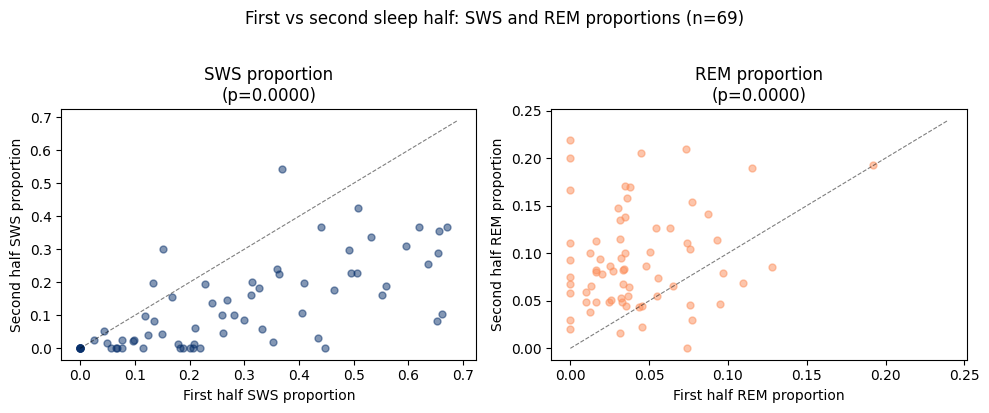

In [5]:
w_sws, p_sws = stats.wilcoxon(df_temp['first_sws'], df_temp['second_sws'],
                               alternative='greater')   # H1: first > second
w_rem, p_rem = stats.wilcoxon(df_temp['first_rem'], df_temp['second_rem'],
                               alternative='less')       # H1: first < second

# Effect size: rank-biserial correlation
def rank_biserial(w, n):
    return 1 - (4 * w) / (n * (n + 1))

rb_sws = rank_biserial(w_sws, len(df_temp))
rb_rem = rank_biserial(w_rem, len(df_temp))

print('=== Group-level SWS-REM gradient (Wilcoxon signed-rank) ===')
print(f'SWS decline (first > second): W={w_sws:.1f}  p={p_sws:.4f}  r={rb_sws:.3f}')
print(f'REM increase (second > first): W={w_rem:.1f}  p={p_rem:.4f}  r={rb_rem:.3f}')

# Visualise first vs second half
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, metric, label, pval, c1, c2 in zip(
    axes,
    [('first_sws','second_sws'), ('first_rem','second_rem')],
    ['SWS proportion', 'REM proportion'],
    [p_sws, p_rem],
    ['#08306b', '#fc8d59'],
    ['#4292c6', '#fdae6b'],
):
    m1, m2 = df_temp[metric[0]], df_temp[metric[1]]
    ax.scatter(m1, m2, alpha=0.5, s=25, color=c1)
    lim = max(m1.max(), m2.max()) + 0.02
    ax.plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.5)
    ax.set_xlabel(f'First half {label}')
    ax.set_ylabel(f'Second half {label}')
    ax.set_title(f'{label}\n(p={pval:.4f})')
plt.suptitle('First vs second sleep half: SWS and REM proportions (n=69)', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'temporal_halves_scatter.png', dpi=300)
plt.show()

## 5.5  Individual variability structure — RQ1 (core result)

Does first-half SWS proportion predict the magnitude of SWS decline?
This is the between-subject RQ1 question, operationalised via temporal halves.

RQ1: first-half SWS vs SWS delta
  Pearson r = 0.770  p = 0.0000  n = 69


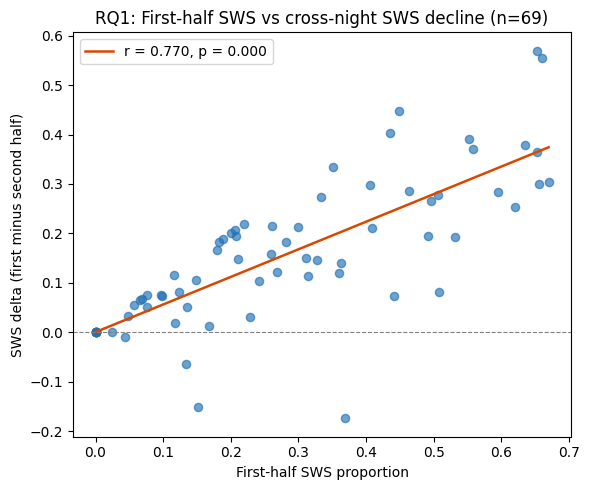


First-half SWS vs REM increase: r = 0.351  p = 0.0031


In [6]:
rho_rq1, pval_rq1 = stats.pearsonr(df_temp['first_sws'], df_temp['delta_sws'])
print(f'RQ1: first-half SWS vs SWS delta')
print(f'  Pearson r = {rho_rq1:.3f}  p = {pval_rq1:.4f}  n = {len(df_temp)}')

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df_temp['first_sws'], df_temp['delta_sws'],
           color='#2171b5', alpha=0.65, s=35)
m, b = np.polyfit(df_temp['first_sws'], df_temp['delta_sws'], 1)
xs = np.linspace(df_temp['first_sws'].min(), df_temp['first_sws'].max(), 100)
ax.plot(xs, m * xs + b, color='#d94801', lw=1.8,
        label=f'r = {rho_rq1:.3f}, p = {pval_rq1:.3f}')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('First-half SWS proportion')
ax.set_ylabel('SWS delta (first minus second half)')
ax.set_title('RQ1: First-half SWS vs cross-night SWS decline (n=69)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'rq1_scatter.png', dpi=300)
plt.show()

# Also report REM slope correlation
rho_rem, pval_rem = stats.pearsonr(df_temp['first_sws'], df_temp['delta_rem'])
print(f'\nFirst-half SWS vs REM increase: r = {rho_rem:.3f}  p = {pval_rem:.4f}')

## 5.6  Non-decreaser subgroup — RQ3 discriminating cases

Subjects whose SWS does NOT decline (delta_sws <= 0) are the discriminating
cases for RQ3. The two-stage model and SHY make different predictions about
what characterises these subjects.

Non-decreasing SWS subjects: 11 / 69 (15.9%)

Non-decreaser descriptives:
       first_sws  second_sws  first_rem  second_rem  delta_rem
count     11.000      11.000     11.000      11.000     11.000
mean       0.063       0.100      0.068       0.074      0.007
std        0.116       0.179      0.050       0.051      0.047
min        0.000       0.000      0.000       0.000     -0.074
25%        0.000       0.000      0.039       0.044     -0.023
50%        0.000       0.000      0.051       0.075      0.009
75%        0.089       0.125      0.085       0.094      0.044
max        0.370       0.543      0.192       0.192      0.075

Decreaser (monotonic) descriptives:
       first_sws  second_sws  first_rem  second_rem  delta_rem
count     58.000      58.000     58.000      58.000     58.000
mean       0.321       0.128      0.037       0.096      0.059
std        0.194       0.122      0.031       0.051      0.056
min        0.025       0.000      0.000       0.016     -0.043
25%    

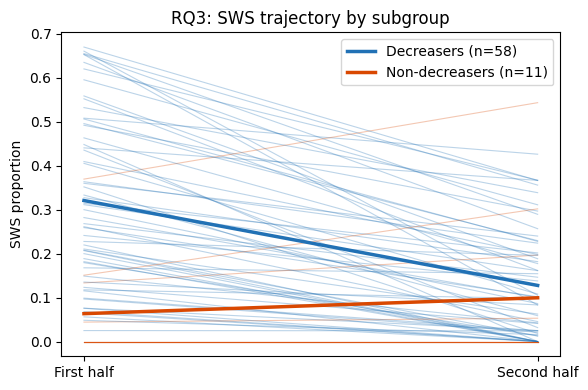

In [7]:
nonmono = df_temp[df_temp['delta_sws'] <= 0].copy()
mono    = df_temp[df_temp['delta_sws'] >  0].copy()

print(f'Non-decreasing SWS subjects: {len(nonmono)} / {len(df_temp)} '
      f'({100*len(nonmono)/len(df_temp):.1f}%)')

print('\nNon-decreaser descriptives:')
print(nonmono[['first_sws','second_sws','first_rem','second_rem','delta_rem']]
      .describe().round(3))

print('\nDecreaser (monotonic) descriptives:')
print(mono[['first_sws','second_sws','first_rem','second_rem','delta_rem']]
      .describe().round(3))

# Mann-Whitney test: do non-decreasers differ from decreasers in first-half SWS?
mw_stat, mw_pval = stats.mannwhitneyu(nonmono['first_sws'], mono['first_sws'],
                                        alternative='two-sided')
print(f'\nFirst-half SWS: non-decreasers vs decreasers')
print(f'  Mann-Whitney U={mw_stat:.1f}  p={mw_pval:.4f}')
print(f'  Non-dec mean: {nonmono["first_sws"].mean():.3f}  '
      f'Dec mean: {mono["first_sws"].mean():.3f}')

# Visualise SWS trajectory for both groups
fig, ax = plt.subplots(figsize=(6, 4))
for _, row in df_temp.iterrows():
    col = '#d94801' if row['delta_sws'] <= 0 else '#2171b5'
    ax.plot([0, 1], [row['first_sws'], row['second_sws']],
            color=col, alpha=0.3, lw=0.8)
ax.plot([0, 1], [mono['first_sws'].mean(), mono['second_sws'].mean()],
        color='#2171b5', lw=2.5, label=f'Decreasers (n={len(mono)})')
ax.plot([0, 1], [nonmono['first_sws'].mean(), nonmono['second_sws'].mean()],
        color='#d94801', lw=2.5, label=f'Non-decreasers (n={len(nonmono)})')
ax.set_xticks([0, 1])
ax.set_xticklabels(['First half', 'Second half'])
ax.set_ylabel('SWS proportion')
ax.set_title('RQ3: SWS trajectory by subgroup')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'rq3_sws_trajectory.png', dpi=300)
plt.show()

---
# Phase 6 — Feature Importance and the Project 1 Bridge (RQ2)

## 6.1  Permutation importance (one-vs-all, LOSO held-out sets)

Cached: re-running loads saved results.

In [8]:
imp_path = RES_DIR / 'importance.npz'

if imp_path.exists():
    d    = np.load(imp_path)
    imp  = d['imp']
    null = d['null']
    print('Loaded cached importance.')
else:
    imp, null = permutation_importance_ova(X, y, sids, n_perms=100, n_jobs=-1)
    np.savez_compressed(imp_path, imp=imp, null=null)
    print('Computed and saved importance.')

sig_mask = above_null_mask(imp, null, pct=95)
print(f'Above-null features per stage: { {STAGE_NAMES[s]: int(sig_mask[s].sum()) for s in range(5)} }')

Loaded cached importance.
Above-null features per stage: {'Wake': 41, 'N1': 20, 'N2': 32, 'N3': 33, 'REM': 42}


## 6.2  Per-stage importance heatmap — Paper Figure 5

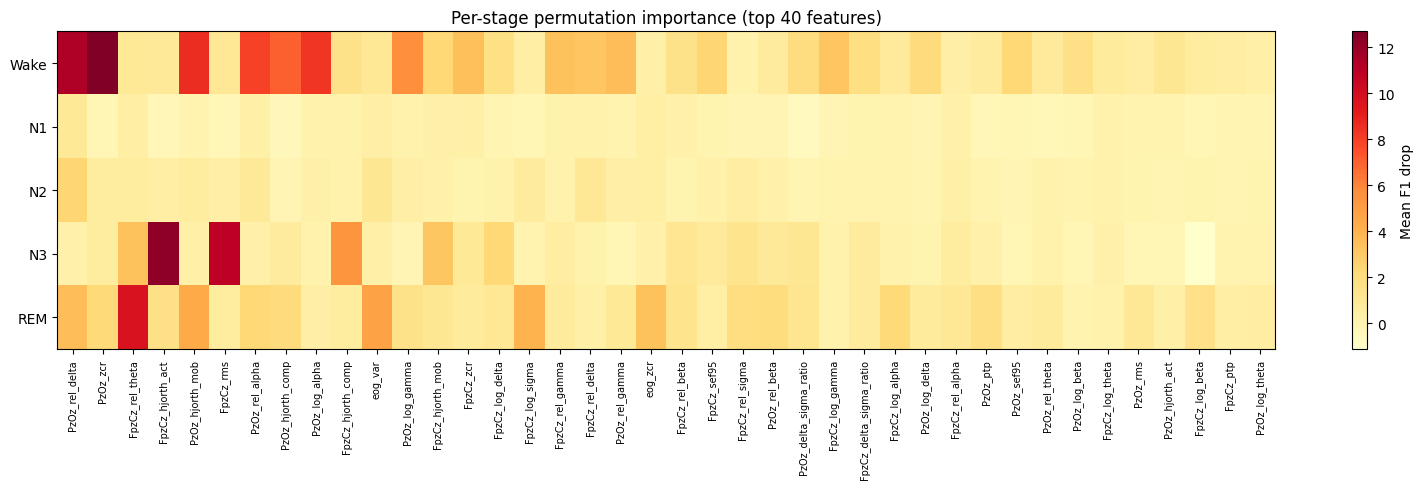

In [9]:
order     = np.argsort(imp.mean(axis=0))[::-1][:40]
imp_sub   = imp[:, order]
names_sub = [feat_names[i] for i in order]

fig, ax = plt.subplots(figsize=(16, 5))
im = ax.imshow(imp_sub, aspect='auto', cmap='YlOrRd')
plt.colorbar(im, ax=ax, label='Mean F1 drop')
ax.set_yticks(range(5))
ax.set_yticklabels(STAGE_NAMES)
ax.set_xticks(range(len(names_sub)))
ax.set_xticklabels(names_sub, rotation=90, fontsize=7)
ax.set_title('Per-stage permutation importance (top 40 features)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'importance_heatmap.png', dpi=300)
plt.show()

## 6.3  Beta and gamma importance: REM vs all other stages

In [10]:
band_imp_by_stage = {}
for si, sn in enumerate(STAGE_NAMES):
    band_imp_by_stage[sn] = band_importance(imp[si], feat_names)

print('Band importance by stage:')
hdr = f'{"Stage":6s}' + ''.join(f'  {b:7s}' for b in BANDS)
print(hdr)
for sn in STAGE_NAMES:
    row = f'{sn:6s}' + ''.join(f'  {band_imp_by_stage[sn][b]:7.4f}' for b in BANDS)
    print(row)

rem_bg  = np.mean([band_imp_by_stage['REM'][b] for b in ('beta','gamma')])
nrem_bg = np.mean([np.mean([band_imp_by_stage[sn][b] for b in ('beta','gamma')])
                   for sn in ('Wake','N1','N2','N3')])
print(f'\nBeta+gamma mean importance  REM: {rem_bg:.4f}  non-REM: {nrem_bg:.4f}')

Band importance by stage:
Stage   delta    theta    alpha    sigma    beta     gamma  
Wake     3.6650   0.7089   4.3355   0.7250   1.1407   3.9291
N1       0.0209   0.0324   0.1314  -0.2032  -0.0781   0.0149
N2       0.5671   0.1734   0.3720   0.2696   0.0432   0.2185
N3       0.7199   0.9050   0.2752   0.6219   0.1724   0.0615
REM      1.2683   2.7858   1.4722   1.3364   1.2454   0.8193

Beta+gamma mean importance  REM: 1.0323  non-REM: 0.6878


## 6.4  Early-night vs late-night REM importance

Positional split of clean REM epochs (first vs second half within subject).
Metric is mean absolute deviation (feature variance proxy, not permutation
importance). Interpret directionally only.

In [11]:
early_imps, late_imps = [], []

for sid in subjects:
    sc_path = SC_DIR / f'SC{sid:02d}.npz'
    if not sc_path.exists():
        continue
    true_labels = np.load(sc_path)['labels']
    cycles = detect_cycles(true_labels)
    if len(cycles) < 2:
        continue

    sub_mask      = sids == sid
    sub_X, sub_y  = X[sub_mask], y[sub_mask]
    rem_positions = np.where(sub_y == 4)[0]
    n_rem = len(rem_positions)
    if n_rem < 4:
        continue
    mid = n_rem // 2
    early_X = sub_X[rem_positions[:mid]]
    late_X  = sub_X[rem_positions[mid:]]
    early_imps.append(np.abs(early_X - early_X.mean(0)).mean(0))
    late_imps.append(np.abs(late_X  - late_X.mean(0)).mean(0))

if early_imps:
    early_mean = np.mean(early_imps, axis=0)
    late_mean  = np.mean(late_imps,  axis=0)
    print('Early vs late REM beta/gamma feature variance (proxy, not permutation importance):')
    for b in ('beta', 'gamma'):
        b_idx = [i for i, n in enumerate(feat_names) if b in n]
        e_val = early_mean[b_idx].mean()
        l_val = late_mean[b_idx].mean()
        print(f'  {b:5s}  early={e_val:.5f}  late={l_val:.5f}  ratio={l_val/e_val:.3f}')
    print('  Note: ratio < 1 indicates higher variance in early-night REM.')
    print('  This does not support the late-night consolidation prediction.')
    print('  Interpret with caution: variance differs from permutation importance.')
else:
    print('No subjects with >= 2 cycles and >= 4 clean REM epochs.')

Early vs late REM beta/gamma feature variance (proxy, not permutation importance):
  beta   early=0.00723  late=0.00510  ratio=0.705
  gamma  early=0.00116  late=0.00097  ratio=0.833
  Note: ratio < 1 indicates higher variance in early-night REM.
  This does not support the late-night consolidation prediction.
  Interpret with caution: variance differs from permutation importance.


## 6.5  Project 1 cross-domain Spearman comparison — Paper Figure 6

In [12]:
P1_BAND_IMP = {
    'theta': 0.000166,
    'alpha': 0.000450,
    'beta':  0.000907,
    'gamma': 0.000314,
}

rem_imp_row = imp[4]
rho, pval, bands, our_vals, p1_vals = compare_project1(rem_imp_row, feat_names, P1_BAND_IMP)

print(f'Spearman rho = {rho:.3f}  p = {pval:.4f}')
print(f'Comparison restricted to overlapping bands: {bands}')
print()
print(f'{"Band":8s}  {"This paper (REM imp)":>22s}  {"Project 1 (valence imp)":>23s}')
for b, o, p in zip(bands, our_vals, p1_vals):
    print(f'{b:8s}  {o:22.5f}  {p:23.6f}')

print()
print('Interpretation: rho = -0.40 (non-significant, n=4 bands).')
print('REM rank order: theta > alpha > beta > gamma.')
print('P1 valence rank order: beta > alpha > gamma > theta.')
print('Theta dominates REM (expected: hallmark of REM EEG); beta/gamma dominate valence.')
print('The spectral geometries are substantially different, consistent with the')
print('representational reorganization account over reactivation fidelity.')
print('Beta+gamma are elevated in REM vs non-REM (1.03 vs 0.69) — partial continuity.')

Spearman rho = -0.400  p = 0.6000
Comparison restricted to overlapping bands: ['theta', 'alpha', 'beta', 'gamma']

Band        This paper (REM imp)  Project 1 (valence imp)
theta                    2.78577                 0.000166
alpha                    1.47222                 0.000450
beta                     1.24540                 0.000907
gamma                    0.81928                 0.000314

Interpretation: rho = -0.40 (non-significant, n=4 bands).
REM rank order: theta > alpha > beta > gamma.
P1 valence rank order: beta > alpha > gamma > theta.
Theta dominates REM (expected: hallmark of REM EEG); beta/gamma dominate valence.
The spectral geometries are substantially different, consistent with the
representational reorganization account over reactivation fidelity.
Beta+gamma are elevated in REM vs non-REM (1.03 vs 0.69) — partial continuity.


## 6.6  Save all results for Phase 8 (paper writing)

In [13]:
import json

results_summary = {
    # Cycle detection (supplementary)
    'n_subjects_cycles':       int(df_cyc['subject'].nunique()) if len(df_cyc) else 0,
    'n_subjects_3plus_cycles': int((df_cyc.groupby('subject').size() >= 3).sum()) if len(df_cyc) else 0,
    # First-REM latency (all 69 subjects)
    'frl_n_subjects':          int(len(frl_series)),
    'frl_mean_min':            float(frl_series.mean()),
    'frl_median_min':          float(frl_series.median()),
    'frl_sd_min':              float(frl_series.std()),
    # Temporal macrostructure (RQ1)
    'temp_n_subjects':         int(len(df_temp)),
    'sws_first_mean':          float(df_temp['first_sws'].mean()),
    'sws_second_mean':         float(df_temp['second_sws'].mean()),
    'rem_first_mean':          float(df_temp['first_rem'].mean()),
    'rem_second_mean':         float(df_temp['second_rem'].mean()),
    'wilcoxon_sws_p':          float(p_sws),
    'wilcoxon_rem_p':          float(p_rem),
    'rb_sws':                  float(rb_sws),
    'rb_rem':                  float(rb_rem),
    'rq1_pearson_r':           float(rho_rq1),
    'rq1_pearson_p':           float(pval_rq1),
    'rq1_rem_pearson_r':       float(rho_rem),
    'rq1_rem_pearson_p':       float(pval_rem),
    # RQ3
    'n_nonmono_temp':          int(len(nonmono)),
    'pct_nonmono_temp':        float(100 * len(nonmono) / len(df_temp)),
    'mw_nonmono_p':            float(mw_pval),
    # RQ2
    'rq2_spearman_rho':        float(rho),
    'rq2_spearman_p':          float(pval),
    'rem_beta_imp':            float(band_imp_by_stage['REM']['beta']),
    'rem_gamma_imp':           float(band_imp_by_stage['REM']['gamma']),
    'rem_theta_imp':           float(band_imp_by_stage['REM']['theta']),
    'rem_bg_mean':             float(rem_bg),
    'nrem_bg_mean':            float(nrem_bg),
}

with open(RES_DIR / 'results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print('Results summary saved.')
print(json.dumps(results_summary, indent=2))

Results summary saved.
{
  "n_subjects_cycles": 13,
  "n_subjects_3plus_cycles": 1,
  "frl_n_subjects": 69,
  "frl_mean_min": 18.528985507246375,
  "frl_median_min": 16.5,
  "frl_sd_min": 11.772626542975663,
  "temp_n_subjects": 69,
  "sws_first_mean": 0.27978761208652636,
  "sws_second_mean": 0.12319548821524925,
  "rem_first_mean": 0.04186788965382352,
  "rem_second_mean": 0.09251686478687363,
  "wilcoxon_sws_p": 1.1905257947229047e-10,
  "wilcoxon_rem_p": 3.4524655248788495e-09,
  "rb_sws": -0.5569358178053829,
  "rb_rem": 0.8459627329192547,
  "rq1_pearson_r": 0.7701553810704168,
  "rq1_pearson_p": 1.030190621931439e-14,
  "rq1_rem_pearson_r": 0.35126512664247433,
  "rq1_rem_pearson_p": 0.0030818831121966887,
  "n_nonmono_temp": 11,
  "pct_nonmono_temp": 15.942028985507246,
  "mw_nonmono_p": 2.9943845564166595e-05,
  "rq2_spearman_rho": -0.39999999999999997,
  "rq2_spearman_p": 0.6,
  "rem_beta_imp": 1.2454048659020016,
  "rem_gamma_imp": 0.8192826818727744,
  "rem_theta_imp": 2.78